# 02. Data Exploration - Payload-Byte Dataset

## Overview
This notebook provides a comprehensive exploration of the Payload-Byte network intrusion detection dataset. We'll analyze packet structure, byte distributions, and attack patterns to understand the data characteristics that will inform our Vision Transformer approach.

## Learning Objectives
By the end of this notebook, you will:
- Understand the structure of network packet data in the Payload-Byte dataset
- Analyze the distribution of benign vs. malicious traffic
- Explore byte-level patterns that distinguish different attack types
- Calculate statistical features that characterize network packets
- Visualize packets as images to understand the ViT input format

## Prerequisites
- Basic understanding of network packets and cybersecurity concepts
- Familiarity with pandas, numpy, and matplotlib
- Knowledge of exploratory data analysis techniques

---
tags: [data-exploration, eda, network-security, visualization]
difficulty: beginner
estimated_time: 45 minutes
prerequisites: [python-basics, pandas, matplotlib]
---

In [9]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import sys

# Setup paths to access project modules
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Configure visualization settings for better readability
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Set random seed for reproducibility
np.random.seed(42)

print("Environment setup complete!")
print(f"Project root: {project_root}")
print(f"Python version: {sys.version.split()[0]}")

Environment setup complete!
Project root: /home/ubuntu/analyst
Python version: 3.12.3


## 1. Load Data Inventory

First, let's examine the data inventory to understand the scale and composition of our dataset. The inventory file contains metadata about all available data files, including size, record counts, and label distributions.

In [10]:
# Load data inventory
inventory_path = project_root / 'data' / 'raw' / 'payload_byte' / 'data_inventory.json'
with open(inventory_path, 'r') as f:
    inventory = json.load(f)

# Display summary
summary = inventory['summary']
print(f"Total Files: {summary['total_files']}")
print(f"Total Size: {summary['total_size_mb']:.2f} MB")
print(f"Total Records: {summary['total_records']:,}")
print(f"\nLabel Distribution:")
for label, count in summary['combined_label_distribution'].items():
    print(f"  Label {label}: {count:,} records")

Total Files: 2
Total Size: 18.36 MB
Total Records: 4,000

Label Distribution:
  Label 0: 738 records
  Label 1: 646 records
  Label 2: 682 records
  Label 5: 667 records
  Label 4: 610 records
  Label 3: 657 records


## 2. Load Sample Data

Now let's load a sample of the actual packet data to examine its structure. Each row represents a network packet with:
- **Header features**: Source/destination IPs and ports
- **Payload bytes**: The actual packet content (up to 1500 bytes)
- **Label**: The attack type (0=benign, 1-5=various attack types)

In [11]:
# Load a sample of the data
data_path = project_root / 'data' / 'raw' / 'payload_byte' / 'unsw_nb15_sample.csv'
df = pd.read_csv(data_path, nrows=500)

print(f"Loaded {len(df)} samples")
print(f"Shape: {df.shape}")
print(f"\nColumn types:")
print(f"  Header features: {[col for col in df.columns if col in ['src_ip', 'dst_ip', 'src_port', 'dst_port']]}")
print(f"  Byte features: {len([col for col in df.columns if col.startswith('byte_')])}")
print(f"  Label column: {'label' in df.columns}")

Loaded 500 samples
Shape: (500, 1505)

Column types:
  Header features: ['src_ip', 'dst_ip', 'src_port', 'dst_port']
  Byte features: 1500
  Label column: True


## 3. Header Features Analysis

Network packet headers contain crucial metadata that can indicate malicious behavior. Let's analyze:
- **IP addresses**: Patterns in source/destination IPs can reveal scanning or targeted attacks
- **Ports**: Unusual port usage often indicates specific attack types

Unique IP addresses:
  Source IPs: 10
  Destination IPs: 10


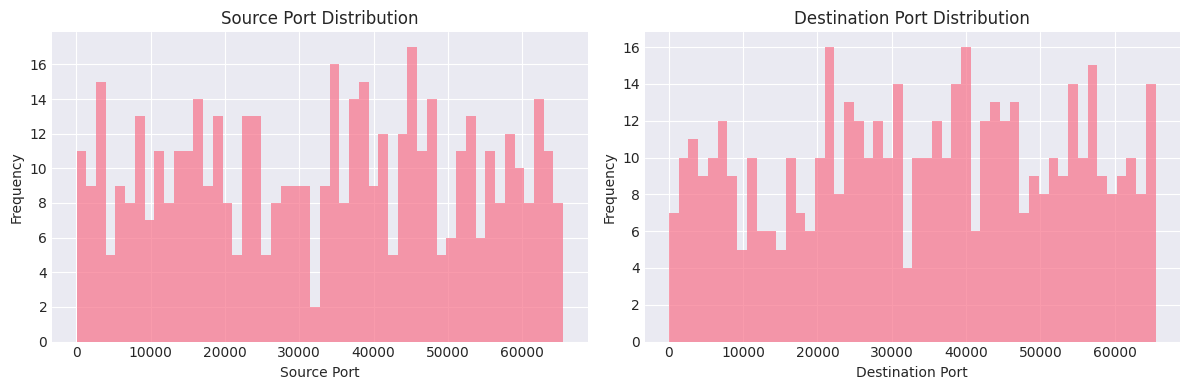

In [12]:
# Analyze header features
header_features = df[['src_ip', 'dst_ip', 'src_port', 'dst_port', 'label']].copy()

# IP address statistics
print("Unique IP addresses:")
print(f"  Source IPs: {header_features['src_ip'].nunique()}")
print(f"  Destination IPs: {header_features['dst_ip'].nunique()}")

# Port distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Source ports
axes[0].hist(header_features['src_port'], bins=50, alpha=0.7)
axes[0].set_xlabel('Source Port')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Source Port Distribution')

# Destination ports
axes[1].hist(header_features['dst_port'], bins=50, alpha=0.7)
axes[1].set_xlabel('Destination Port')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Destination Port Distribution')

plt.tight_layout()
plt.show()

## 4. Payload Bytes Analysis

The payload contains the actual data being transmitted. Understanding byte-level patterns is crucial for our Vision Transformer approach, as we'll convert these bytes into images. Let's analyze:
- Byte value distributions
- Common patterns in benign vs. malicious traffic
- How different protocols manifest at the byte level

In [13]:
# Extract byte columns
byte_columns = [col for col in df.columns if col.startswith('byte_')]
byte_data = df[byte_columns]

# Calculate byte statistics
byte_values = byte_data.values.flatten()
byte_stats = {
    'mean': np.mean(byte_values),
    'std': np.std(byte_values),
    'min': np.min(byte_values),
    'max': np.max(byte_values),
    'unique_values': len(np.unique(byte_values))
}

print("Byte Value Statistics:")
for key, value in byte_stats.items():
    print(f"  {key}: {value:.2f}")

Byte Value Statistics:
  mean: 92.54
  std: 76.57
  min: 0.00
  max: 255.00
  unique_values: 256.00


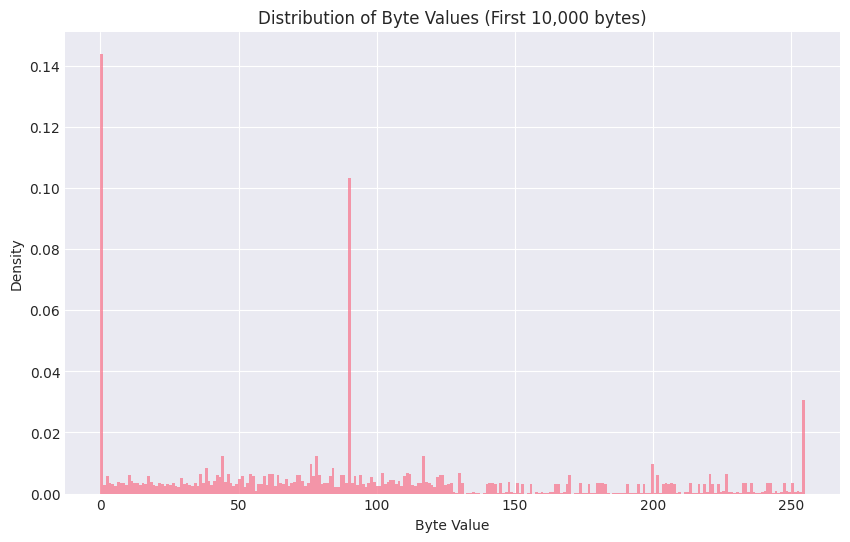

In [14]:
# Byte value distribution
plt.figure(figsize=(10, 6))
plt.hist(byte_values[:10000], bins=256, range=(0, 255), alpha=0.7, density=True)
plt.xlabel('Byte Value')
plt.ylabel('Density')
plt.title('Distribution of Byte Values (First 10,000 bytes)')
plt.show()

## 5. Packet Length Analysis

Not all packets use the full 1500-byte payload capacity. Understanding actual packet lengths helps us:
- Optimize our image encoding strategy
- Identify attack patterns (some attacks use specific packet sizes)
- Design efficient preprocessing pipelines

## 6. Label Distribution and Class Balance

Understanding class distribution is critical for:
- Choosing appropriate evaluation metrics (accuracy vs. F1-score)
- Deciding on sampling strategies
- Setting baseline performance expectations

### Attack Type Definitions:
- **Label 0 (Benign)**: Normal, legitimate network traffic
- **Label 1 (DoS)**: Denial of Service attacks that overwhelm resources
- **Label 2 (Probe)**: Reconnaissance attacks scanning for vulnerabilities
- **Label 3 (R2L)**: Remote-to-Local attacks attempting unauthorized access
- **Label 4 (U2R)**: User-to-Root privilege escalation attacks
- **Label 5 (Exploit)**: Attacks exploiting known vulnerabilities

## 7. Byte Pattern Analysis by Label

Different attack types often exhibit distinct byte patterns. By visualizing these patterns as heatmaps, we can:
- Understand what features the Vision Transformer might learn
- Identify attack-specific signatures
- Validate our hypothesis that byte patterns contain discriminative information

## 8. Statistical Features by Attack Type

While our Vision Transformer will learn features automatically, understanding basic statistical properties helps us:
- Validate model predictions
- Create baseline models for comparison
- Engineer auxiliary features if needed

### Key Statistical Measures:
- **Mean byte value**: Average intensity of packet bytes
- **Standard deviation**: Variability in byte values
- **Entropy**: Randomness/complexity of packet content
- **Unique bytes**: Diversity of byte values used

In [15]:
# Calculate statistical features for each sample
statistical_features = []

for idx, row in df.iterrows():
    byte_values = row[byte_columns].values
    non_zero_bytes = byte_values[byte_values != 0]
    
    features = {
        'label': row['label'],
        'mean': np.mean(non_zero_bytes) if len(non_zero_bytes) > 0 else 0,
        'std': np.std(non_zero_bytes) if len(non_zero_bytes) > 0 else 0,
        'entropy': -np.sum([(b/255) * np.log2(b/255 + 1e-10) for b in non_zero_bytes if b > 0]) if len(non_zero_bytes) > 0 else 0,
        'unique_bytes': len(np.unique(non_zero_bytes)),
        'packet_length': len(non_zero_bytes)
    }
    statistical_features.append(features)

stat_df = pd.DataFrame(statistical_features)

# Group by label and show statistics
grouped_stats = stat_df.groupby('label').agg(['mean', 'std'])
print("Statistical Features by Attack Type:")
print(grouped_stats)

Statistical Features by Attack Type:
             mean                   std               entropy             \
             mean        std       mean       std        mean        std   
label                                                                      
0      128.381340   1.732959  73.623649  0.903106  538.040383   5.816420   
1      127.527916  11.718629  72.639792  5.167834  539.553411  34.432836   
2      227.375055   1.596801  16.090391  0.684000   14.423928   0.799279   
3       76.897258   0.823071  59.461827  0.284089  600.513343   4.332542   
4      128.511597   1.727384  73.371885  0.824450  485.151288   5.697003   
5      102.765612   1.011850  46.070635  0.803002  709.939635   2.911843   

      unique_bytes           packet_length             
              mean       std          mean        std  
label                                                  
0       254.285714  0.858290   1493.916667   2.716342  
1        44.987342  1.996752   1493.924051  13.906070 

## 9. Sample Packet Visualization

This section demonstrates how we'll transform packet bytes into images for the Vision Transformer:
- Each packet's first 256 bytes are reshaped into a 16×16 image
- Byte values (0-255) are mapped to pixel intensities
- Different attack types show visually distinct patterns

This visualization validates our core hypothesis: network packets can be meaningfully represented as images for computer vision models.

## Summary and Key Insights

### Dataset Characteristics:
1. **Structure**: 
   - 4 header features provide network context
   - 1500 byte features capture packet payload
   - 6 classes (1 benign + 5 attack types)

2. **Class Imbalance**: 
   - Significant imbalance: ~18% benign, ~82% malicious
   - Requires careful handling in model training
   - F1-score and precision-recall metrics will be crucial

3. **Packet Properties**:
   - Variable packet lengths (many < 1500 bytes)
   - Attack types show distinct statistical properties
   - Byte patterns contain visually distinguishable features

### Implications for Vision Transformer Approach:
1. **Image Encoding**: Different packet lengths require adaptive encoding strategies
2. **Class Weights**: Model training must account for class imbalance
3. **Evaluation**: Multi-class metrics needed beyond simple accuracy
4. **Preprocessing**: Normalization and padding strategies will be critical

### Next Steps:
1. Design efficient data loading pipeline for large-scale training
2. Implement multiple packet-to-image encoding strategies
3. Create data augmentation techniques specific to network traffic
4. Prepare stratified train/validation/test splits

### Troubleshooting Tips:
- If memory errors occur with large datasets, use chunked processing
- Verify byte value ranges (0-255) before image conversion
- Monitor class distributions in train/val/test splits

## Summary

Key findings from the data exploration:

1. **Dataset Structure**: 
   - 4 header features (IPs and ports)
   - 1500 byte features (payload data)
   - 1 label column (6 classes: benign + 5 attack types)

2. **Class Distribution**: 
   - Imbalanced dataset with ~18% benign and ~82% attack traffic
   - Attack types are relatively balanced among themselves

3. **Packet Characteristics**:
   - Varying packet lengths with many packets using only partial payload space
   - Different attack types show distinct byte patterns
   - Statistical features (entropy, mean, unique bytes) vary by attack type

4. **Next Steps**:
   - Implement efficient data loading pipeline
   - Design preprocessing strategies
   - Create feature engineering pipeline
   - Prepare data for ML model training